In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
import numpy as np
import pandas as pd
import os
from pathlib import Path
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torchvision import transforms

from ilipy import Session
from ilipy.database import DistanceCorrelation
from ilipy import  Session

from rnd.utils.modeling import get_model
from rnd.utils.transform import resize_to_224
from rnd.utils.data_utils import (
    set_ili_run,
    extract_arm_angles,
    create_arm_array,
)

In [3]:
run_number = 6
root_dir = f"./data/fhr{run_number}"
os.makedirs(root_dir, exist_ok=True)
_, _, inspection_id, env, _, start_dist, end_dist = set_ili_run(run_number)

session = Session(environment="research")
session.set_active_inspection(inspection_id)
dist_corr = DistanceCorrelation(session)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

PySettings.cpp(46): ilipy: Build 0.17.2.10867 5d2ea142f2 release-ili-0.17 'Tue Jul 22 21:50:18 2025'
PySettings.cpp(47): Paths modulePath: /home/zmirikha/ilipy/lib/python3.11/site-packages/ilipy, userHomePath: /home/zmirikha, identityPath: /home/zmirikha/.aws/ilipy
Settings.cpp(246): Settings: loading settings from /home/zmirikha/ilipy/lib/python3.11/site-packages/ilipy/Data/Environments/defaults.json
Settings.cpp(246): Settings: loading settings from /home/zmirikha/ilipy/lib/python3.11/site-packages/ilipy/Data/Environments/research.json
PyAuthenticator.cpp(239): Attempting an IAM role login as no username and password or environment variables were provided.
CognitoAuthenticator.cpp(158): Using Cognito Credentials
CognitoAuthenticator.cpp(842): Login Successful.
CognitoAuthenticator.cpp(842): Login Successful.
CognitoAuthenticator.cpp(883): Logged in as username: zahra.mirikharaji
CognitoAuthenticator.cpp(883): Logged in as username: zahra.mirikharaji
DatabaseWebSocket.cpp(168): WebSoc

In [4]:
class PreprocessingModel(nn.Module):
    def __init__(self, model, transform):
        super().__init__()
        self.model = model
        self.transform = transform

    def forward(self, input_np_image):
        # Apply transform to NumPy image (expects single image, not batch)
        x = self.transform(input_np_image)
        x = x.unsqueeze(0)  # Add batch dimension
        return self.model(x)

In [5]:
def load_model(model_name, dense_units, dropout, model_path):
    """
    Load a PyTorch model with weights and return it along with the transform.

    Returns:
        model (torch.nn.Module): The loaded model ready for inference.
        transform (callable): The image preprocessing pipeline.
        weights: The weight metadata used for normalization.
    """
    model, weights = get_model(model_name, dense_units, dropout)
    model.load_state_dict(torch.load(model_path))
    model.eval()
    return model, weights

    # transform = transforms.Compose([
    #     transforms.Lambda(resize_to_224),
    #     transforms.ToTensor(),
    #     transforms.Lambda(lambda x: x.expand(3, -1, -1)),
    #     transforms.Normalize(mean=weights.transforms().mean, std=weights.transforms().std),
    # ])

    # wrapped_model = PreprocessingModel(model, transform)
    #return wrapped_model

DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: 

In [6]:
model, weights = load_model("resnet", 128, 0.5, "models/dent_models/resnet_final_0_1_classifier.pth")

In [7]:
transform = transforms.Compose([
    transforms.Lambda(resize_to_224),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.expand(3, -1, -1)),
    transforms.Normalize(mean=weights.transforms().mean, std=weights.transforms().std),
])

In [8]:
def gen_image(img_start, length= 0.3, show_im=True):
    img_range = (img_start, img_start + length)
    tick_sampling_interval = 10

    arm_angles = extract_arm_angles(session, dist_corr, img_range, tick_sampling_interval=tick_sampling_interval)
    num_tick_samples = int(length * 10000 / tick_sampling_interval)
    img = create_arm_array(arm_angles, num_tick_samples=num_tick_samples, normalize=True)
    # img = np.roll(img, shift=100)
    if show_im: 
        plt.imshow(
            img.T, cmap="inferno", origin="lower", aspect="auto",
            interpolation="nearest",
        )

        plt.axis("off")
        plt.show()
    return img

DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy


In [2]:
model.eval()
preds = []
probs = []
patch_length = 0.3
stride = 0.15
ranges = [(start, start + patch_length) for start in np.arange(start_dist, end_dist - patch_length + stride, stride)]

with torch.no_grad():
    for img_range in ranges:
        img = gen_image(img_range[0], show_im=False)
        transformed_img = transform(img)  # Convert to tensor and normalize
        transformed_img = transformed_img.unsqueeze(0)
        raw_outputs = model(transformed_img)
        preds.append(raw_outputs.argmax())
        probs.append(raw_outputs.softmax(dim=1).cpu().numpy().max())

NameError: name 'model' is not defined

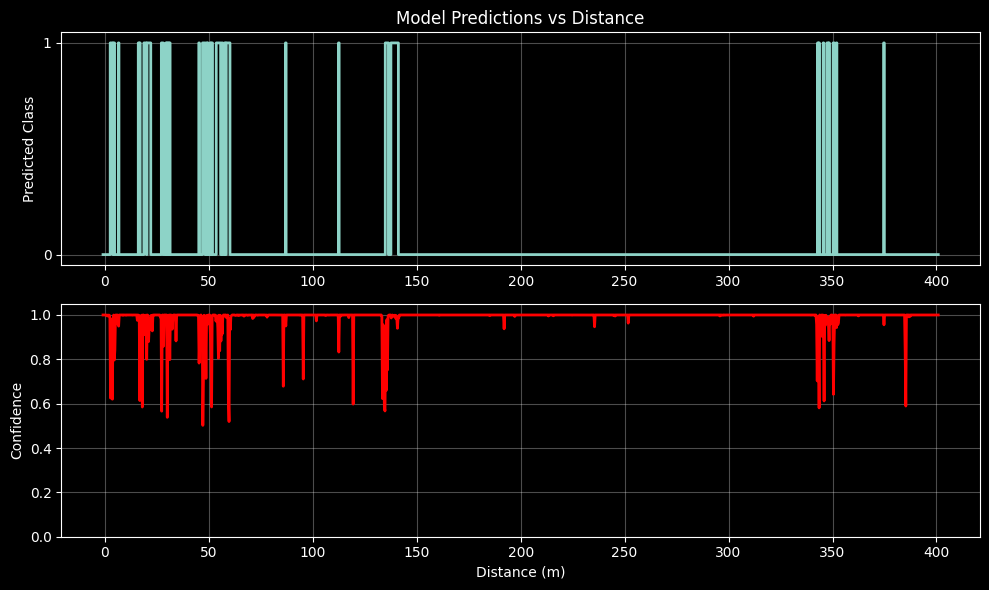

In [19]:
# Plot predictions
plt.style.use('dark_background')
plt.figure(figsize=(10, 6))

# Create x-axis points
patch_length = 0.3
x_points = np.arange(start_dist, end_dist, patch_length)

# Plot class predictions (0 or 1)
plt.subplot(2, 1, 1)
plt.step(x_points[:1340]+patch_length/2, preds, where='mid', linewidth=2)
plt.ylabel('Predicted Class')
plt.title('Model Predictions vs Distance')
plt.grid(True, alpha=0.3)
plt.yticks([0, 1])

# Plot confidence probabilities
plt.subplot(2, 1, 2)
plt.plot(x_points[:1340]+0.15, probs, 'r-', linewidth=2)
plt.xlabel('Distance (m)')
plt.ylabel('Confidence')
plt.grid(True, alpha=0.3)
plt.ylim(0, 1.05)

plt.tight_layout()
plt.show()

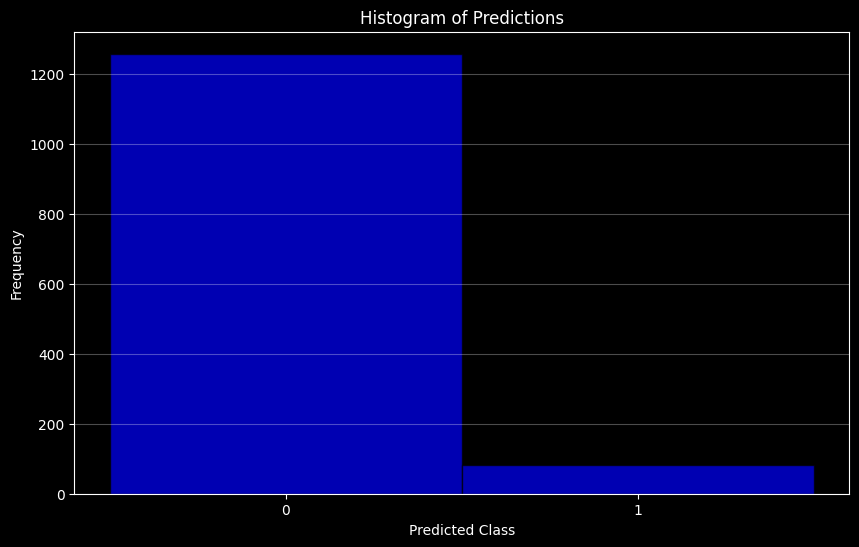

In [20]:
#histogram of preds
plt.figure(figsize=(10, 6))
plt.hist(preds, bins=np.arange(-0.5, 2, 1), alpha=0.7, color='blue', edgecolor='black')
plt.xticks([0, 1])
plt.xlabel('Predicted Class')
plt.ylabel('Frequency')
plt.title('Histogram of Predictions')
plt.grid(axis='y', alpha=0.3)
plt.show()

[  2.6   2.9   3.2   3.5   4.1   4.4   6.5  16.1  16.7  18.8  19.1  19.4
  19.7  20.3  20.6  20.9  21.2  21.5  21.8  27.2  27.5  27.8  29.3  29.9
  30.5  31.1  45.2  47.   47.3  47.6  47.9  48.8  49.4  50.6  51.2  51.5
  53.6  53.9  54.2  54.5  54.8  55.1  55.4  56.3  57.5  57.8  58.4  58.7
  59.   59.3  59.6  59.9  86.9 112.4 134.9 135.2 135.5 135.8 136.1 137.6
 137.9 138.2 138.5 138.8 139.1 139.4 139.7 140.  140.3 140.6 140.9 342.8
 343.4 345.5 347.3 347.6 348.2 350.3 350.6 351.8 374.6]


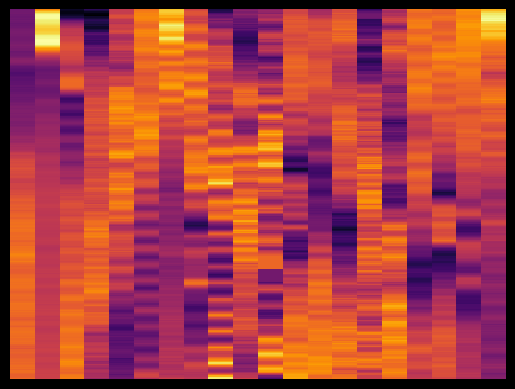

TypeError: conv2d() received an invalid combination of arguments - got (numpy.ndarray, Parameter, NoneType, tuple, tuple, tuple, int), but expected one of:
 * (Tensor input, Tensor weight, Tensor bias, tuple of ints stride, tuple of ints padding, tuple of ints dilation, int groups)
      didn't match because some of the arguments have invalid types: (!numpy.ndarray!, !Parameter!, !NoneType!, !tuple of (int, int)!, !tuple of (int, int)!, !tuple of (int, int)!, int)
 * (Tensor input, Tensor weight, Tensor bias, tuple of ints stride, str padding, tuple of ints dilation, int groups)
      didn't match because some of the arguments have invalid types: (!numpy.ndarray!, !Parameter!, !NoneType!, !tuple of (int, int)!, !tuple of (int, int)!, !tuple of (int, int)!, int)


In [21]:

positive_indices = np.where(np.array(preds) == 1)[0]
positive_VD = positive_indices * 0.3 + start_dist
positive_probs = [probs[i] for i in positive_indices]
patch_length = 0.3
print(positive_VD)
out_dir = os.path.join(root_dir, "test/pos")
os.makedirs(out_dir, exist_ok=True)
model.eval()

for img_start in positive_VD:
    img = gen_image(img_start, show_im=True)
    np.save(os.path.join(out_dir, f"img_{img_start+patch_length/2:.2f}"), img)

    raw_outputs = model(img)
    pred = raw_outputs.argmax()
    prob = raw_outputs.softmax(dim=1).detach().cpu().numpy().max()
    print("VD:", img_start, "Prediction:", pred, "Probability:", prob)




In [ ]:
from rnd.scripts.train import visualize_gradcam
from rnd.utils.dataset import NumpyImageFolder
from torch.utils.data import DataLoader

gradcam_dir = os.path.join(root_dir, "gradcam")
os.makedirs(gradcam_dir, exist_ok=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.cuda()


test_ds = NumpyImageFolder(root_dir=os.path.join(root_dir, "test"), transform=transform, debug=True)
test_loader = DataLoader(test_ds, batch_size=12, shuffle=False)
num_samples = visualize_gradcam(model, test_loader, device, gradcam_dir, num_positive_samples=86, target_layer="base_model.layer4")

DbHealthCheck.cpp(146): Database service health check complete: Healthy


DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
